# Birth Only Model
Experiment:
- only births,
- no death,
- no adhesion,
- compare the three lattices,
- compute the mean evolution over multiple realizations,
- plot one example trajectory/snapshot set for each lattice,
- fit the front-growth exponents.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import (
    make_lattice,
    make_birth_kernel,
    ModelConfig,
    NoAdhesion,
    CultureSimulator,
)

from lib import (
    aggregate_results,
    fit_power_law_exponent,
    plot_observables,
    plot_snapshots,
    plot_ensemble_curve,
)

## Global parameters

In [2]:
# ----------------------------
# Global parameters
# ----------------------------
update_source = "cell_driven"   # or "empty_driven"
r_birth = 1.0
seed_radius = 5.0

t_final = 100.0
n_observations = 201
observation_times = np.linspace(0.0, t_final, n_observations)

n_runs = 20
base_seed = 12345

# Large enough so the colony does not strongly feel the boundary too early
nrows = 201
ncols = 201

lattice_kinds = ["square", "triangular", "hexagonal"]

# Helper - Run one realization

In [3]:
def run_single_birth_only_realization(
    lattice_kind: str,
    update_source: str,
    seed: int,
    nrows: int = 201,
    ncols: int = 201,
    seed_radius: float = 5.0,
    t_final: float = 100.0,
    observation_times=None,
    store_snapshots: bool = False,
):
    lattice = make_lattice(kind=lattice_kind, nrows=nrows, ncols=ncols, periodic=False)
    simulator = CultureSimulator(lattice=lattice)
    initial_state = lattice.make_disk_state(radius=seed_radius)

    config = ModelConfig(
        birth_kernel=make_birth_kernel(update_source),
        r_birth=1.0,
        r_death=0.0,
        birth_modifier=NoAdhesion(),
        death_modifier=NoAdhesion(),
    )

    result = simulator.run(
        initial_state=initial_state,
        config=config,
        t_final=t_final,
        rng=np.random.default_rng(seed),
        observation_times=observation_times,
        store_snapshots=store_snapshots,
    )

    return lattice, result

## Helper - Run Ensamble

In [4]:
def run_birth_only_ensemble(
    lattice_kind: str,
    update_source: str,
    n_runs: int,
    base_seed: int,
    nrows: int = 201,
    ncols: int = 201,
    seed_radius: float = 5.0,
    t_final: float = 100.0,
    observation_times=None,
):
    lattice = make_lattice(kind=lattice_kind, nrows=nrows, ncols=ncols, periodic=False)
    simulator = CultureSimulator(lattice=lattice)
    initial_state = lattice.make_disk_state(radius=seed_radius)

    results = []

    for i in range(n_runs):
        config = ModelConfig(
            birth_kernel=make_birth_kernel(update_source),
            r_birth=1.0,
            r_death=0.0,
            birth_modifier=NoAdhesion(),
            death_modifier=NoAdhesion(),
        )

        rng = np.random.default_rng(base_seed + i)

        result = simulator.run(
            initial_state=initial_state,
            config=config,
            t_final=t_final,
            rng=rng,
            observation_times=observation_times,
            store_snapshots=False,
        )
        results.append(result)

    return lattice, results

## Example realization per lattice type

In [5]:
example_results = {}
example_lattices = {}

snapshot_times = [0.0, 10.0, 25.0, 50.0, 100.0]

for j, lattice_kind in enumerate(lattice_kinds):
    lattice, result = run_single_birth_only_realization(
        lattice_kind=lattice_kind,
        update_source=update_source,
        seed=base_seed + 1000 * j,
        nrows=nrows,
        ncols=ncols,
        seed_radius=seed_radius,
        t_final=t_final,
        observation_times=observation_times,
        store_snapshots=True,
    )
    example_lattices[lattice_kind] = lattice
    example_results[lattice_kind] = result

Time series per lattice


Example trajectory for lattice: square


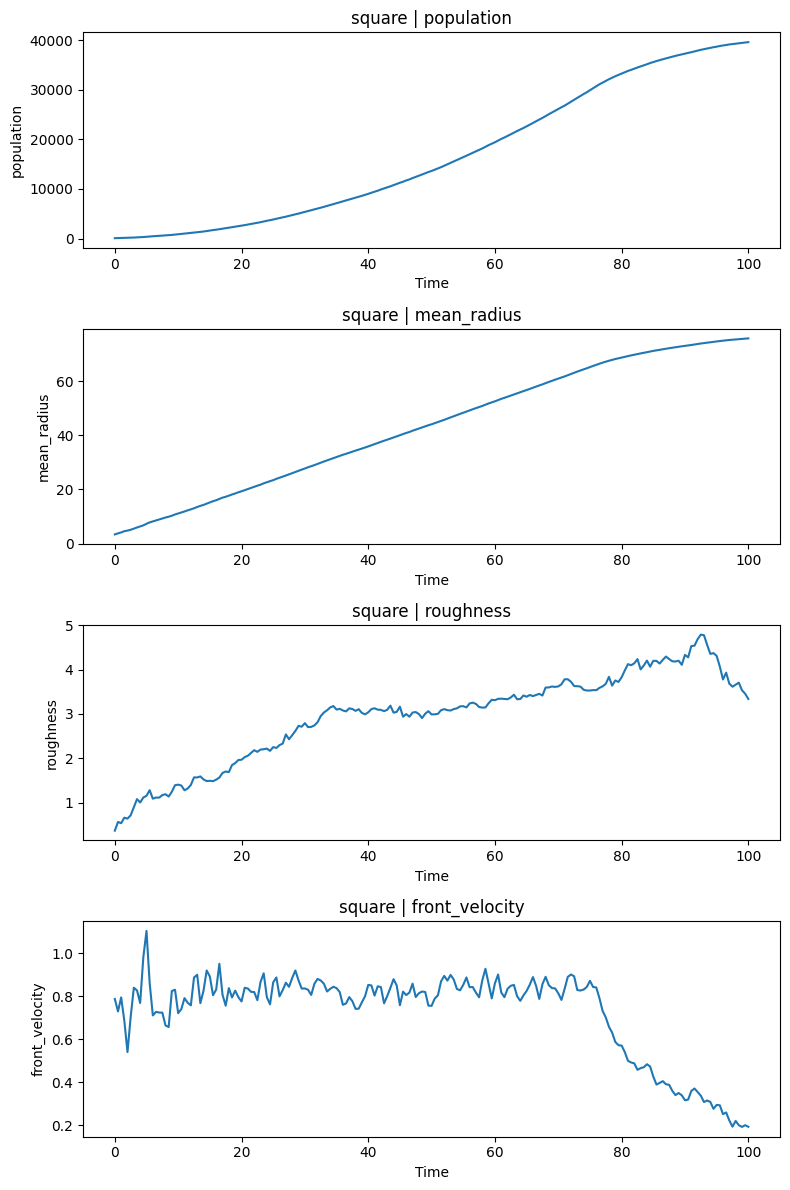


Example trajectory for lattice: triangular


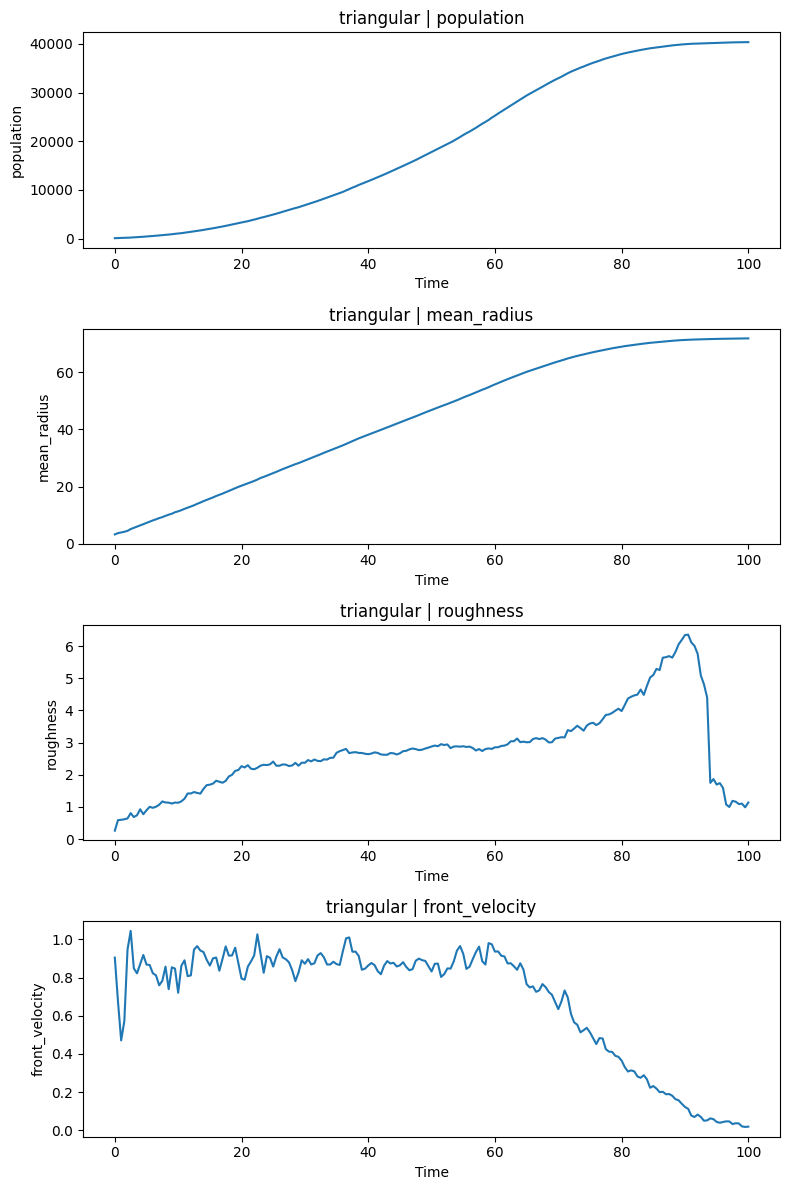


Example trajectory for lattice: hexagonal


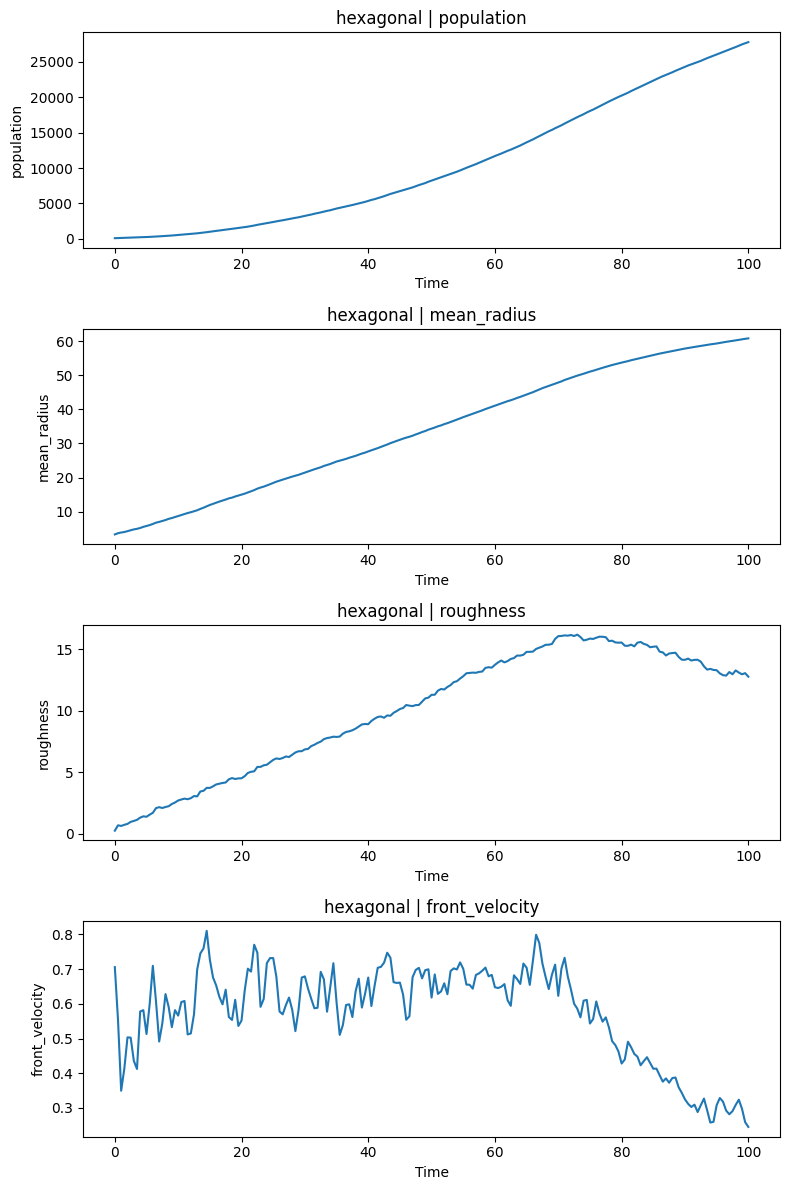

In [6]:
for lattice_kind in lattice_kinds:
    print(f"\nExample trajectory for lattice: {lattice_kind}")
    plot_observables(
        example_results[lattice_kind],
        which=("population", "mean_radius", "roughness", "front_velocity"),
        title_prefix=f"{lattice_kind} | ",
    )

Snapshots per lattice


Snapshots for lattice: square


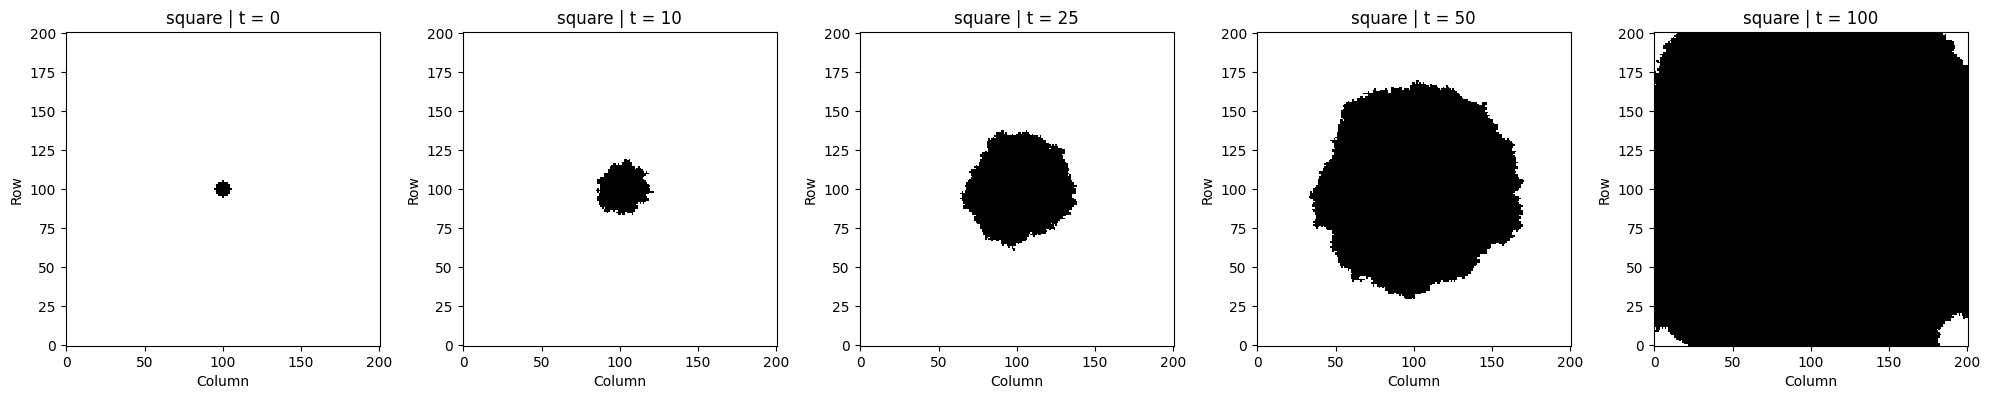


Snapshots for lattice: triangular


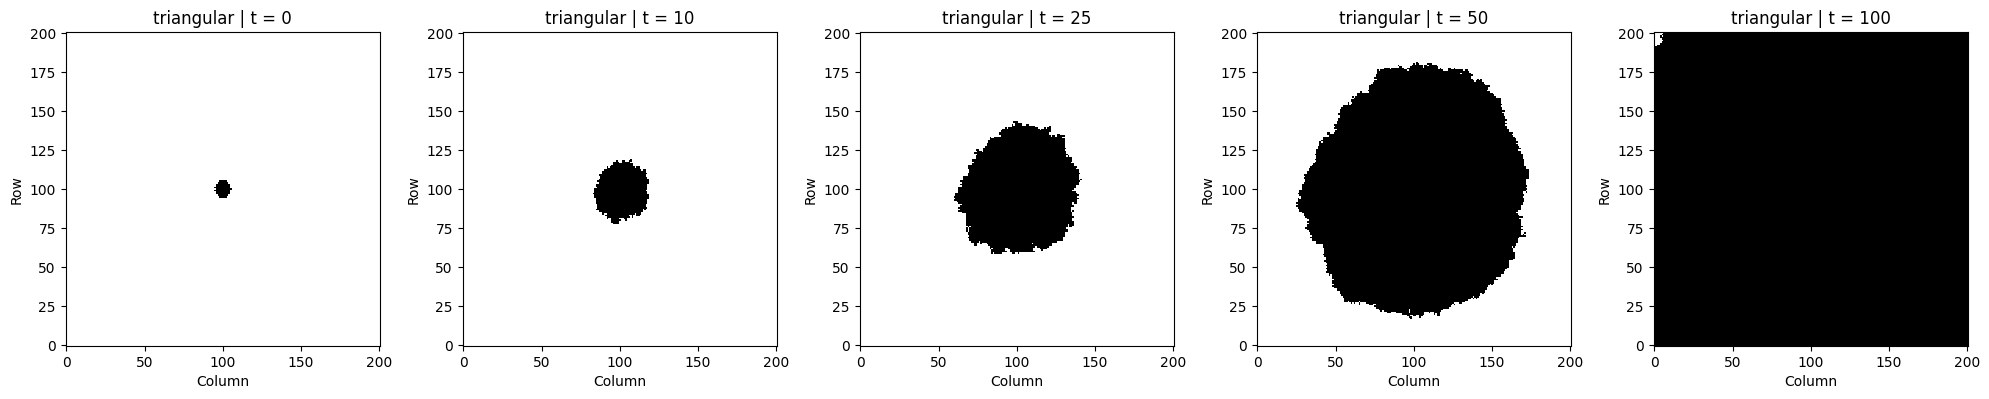


Snapshots for lattice: hexagonal


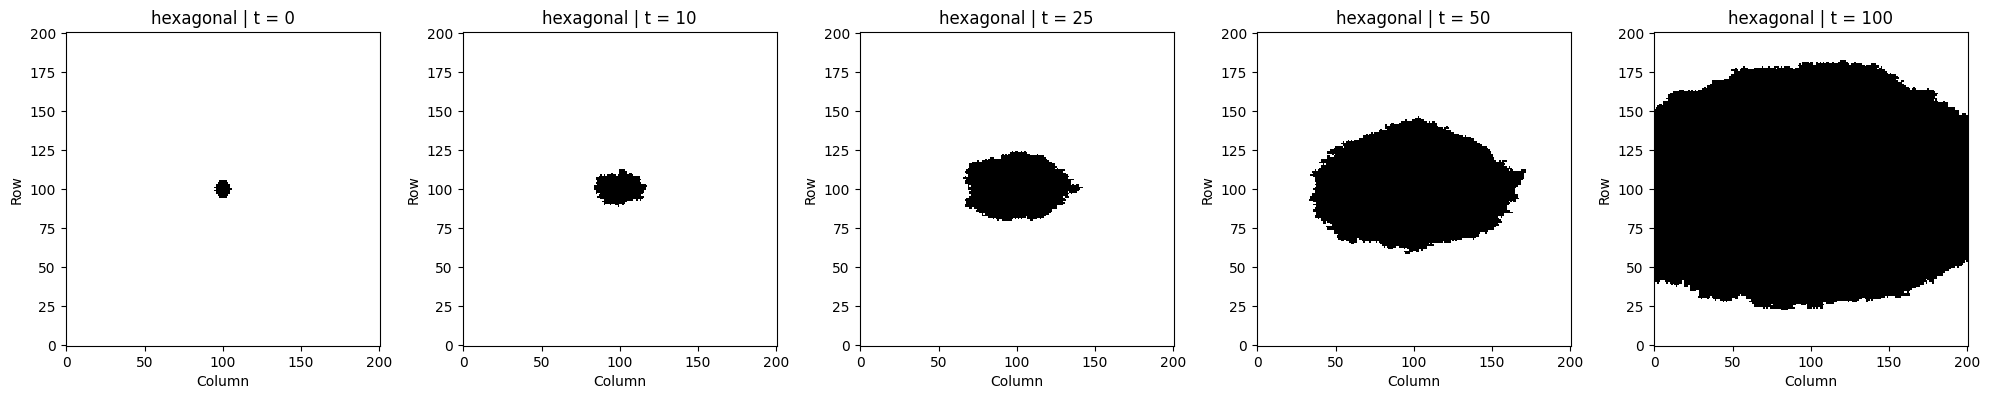

In [7]:
for lattice_kind in lattice_kinds:
    print(f"\nSnapshots for lattice: {lattice_kind}")
    plot_snapshots(
        lattice=example_lattices[lattice_kind],
        result=example_results[lattice_kind],
        times_to_show=snapshot_times,
        title_prefix=f"{lattice_kind} | ",
    )

## Run ensambles

In [8]:
ensemble_results = {}
ensemble_lattices = {}
ensemble_agg = {}

for j, lattice_kind in enumerate(lattice_kinds):
    print(f"Running ensemble for lattice: {lattice_kind}")

    lattice, results = run_birth_only_ensemble(
        lattice_kind=lattice_kind,
        update_source=update_source,
        n_runs=n_runs,
        base_seed=base_seed + 10000 * j,
        nrows=nrows,
        ncols=ncols,
        seed_radius=seed_radius,
        t_final=t_final,
        observation_times=observation_times,
    )

    agg = aggregate_results(results)

    ensemble_lattices[lattice_kind] = lattice
    ensemble_results[lattice_kind] = results
    ensemble_agg[lattice_kind] = agg

Running ensemble for lattice: square
Running ensemble for lattice: triangular
Running ensemble for lattice: hexagonal


Mean population for lattices

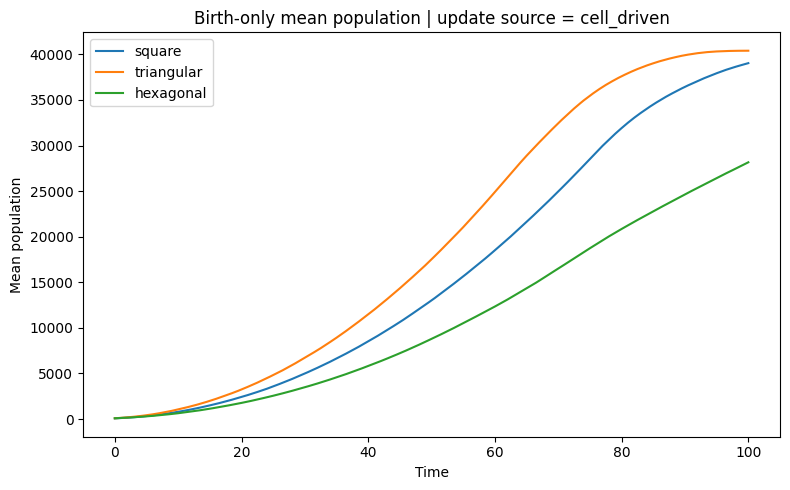

In [9]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]
    plt.plot(agg["time"], agg["mean_population"], label=lattice_kind)

plt.xlabel("Time")
plt.ylabel("Mean population")
plt.title(f"Birth-only mean population | update source = {update_source}")
plt.legend()
plt.tight_layout()
plt.show()

Mean radius for lattices

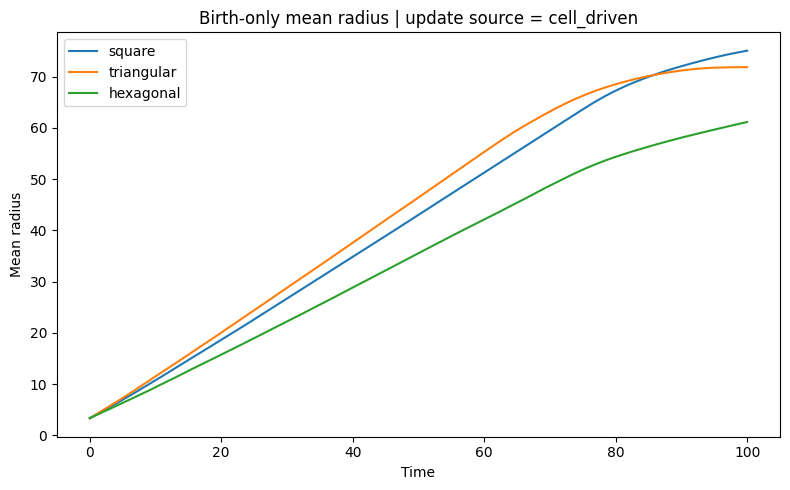

In [10]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]
    plt.plot(agg["time"], agg["mean_radius"], label=lattice_kind)

plt.xlabel("Time")
plt.ylabel("Mean radius")
plt.title(f"Birth-only mean radius | update source = {update_source}")
plt.legend()
plt.tight_layout()
plt.show()

Mean roughness for lattices

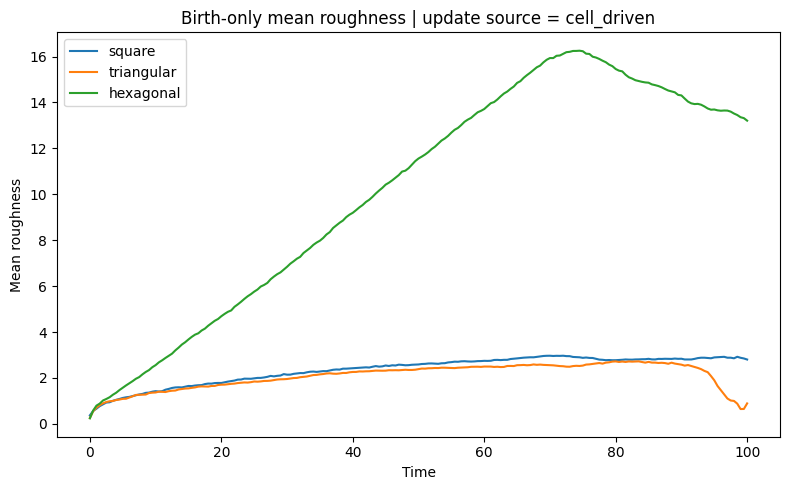

In [11]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]
    plt.plot(agg["time"], agg["mean_roughness"], label=lattice_kind)

plt.xlabel("Time")
plt.ylabel("Mean roughness")
plt.title(f"Birth-only mean roughness | update source = {update_source}")
plt.legend()
plt.tight_layout()
plt.show()

### Fit for Front-Growth Exponents

In [15]:
t_min_fit = 5.0
t_max_fit = 70.0

rows = []

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]

    fit_radius = fit_power_law_exponent(
        times=agg["time"].to_numpy(),
        values=agg["mean_radius"].to_numpy(),
        t_min=t_min_fit,
        t_max=t_max_fit,
    )

    fit_roughness = fit_power_law_exponent(
        times=agg["time"].to_numpy(),
        values=agg["mean_roughness"].to_numpy(),
        t_min=t_min_fit,
        t_max=t_max_fit,
    )

    rows.append(
        {
            "lattice": lattice_kind,
            "radius_exponent": fit_radius["alpha"],
            "radius_prefactor": fit_radius["C"],
            "radius_r2_loglog": fit_radius["r2_loglog"],
            "roughness_exponent": fit_roughness["alpha"],
            "roughness_prefactor": fit_roughness["C"],
            "roughness_r2_loglog": fit_roughness["r2_loglog"],
        }
    )

fit_df = pd.DataFrame(rows)
fit_df

,lattice,radius_exponent,radius_prefactor,radius_r2_loglog,roughness_exponent,roughness_prefactor,roughness_r2_loglog
0,square,0.861111,1.471477,0.996176,0.375189,0.598154,0.997690
1,triangular,0.866146,1.554969,0.996862,0.340964,0.622329,0.993209
2,hexagonal,0.825873,1.390532,0.994423,0.926101,0.303703,0.997179


Log-log plots with fitted curves for mean radius.

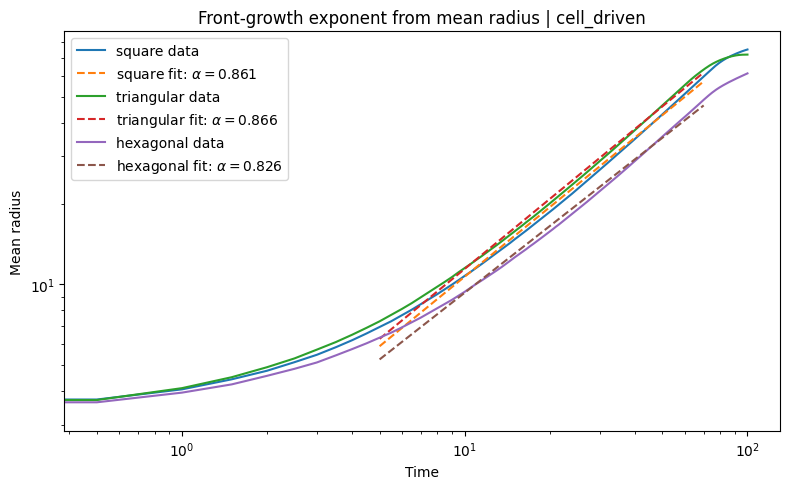

In [16]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]

    t = agg["time"].to_numpy()
    y = agg["mean_radius"].to_numpy()

    fit = fit_power_law_exponent(
        times=t,
        values=y,
        t_min=t_min_fit,
        t_max=t_max_fit,
    )

    mask = (
        np.isfinite(t)
        & np.isfinite(y)
        & (t > 0.0)
        & (y > 0.0)
        & (t >= t_min_fit)
        & (t <= t_max_fit)
    )

    t_fit = t[mask]
    y_model = fit["C"] * t_fit ** fit["alpha"]

    plt.loglog(t, y, label=f"{lattice_kind} data")
    plt.loglog(
        t_fit,
        y_model,
        "--",
        label=fr"{lattice_kind} fit: $\alpha={fit['alpha']:.3f}$",
    )

plt.xlabel("Time")
plt.ylabel("Mean radius")
plt.title(f"Front-growth exponent from mean radius | {update_source}")
plt.legend()
plt.tight_layout()
plt.show()

Log-log plots with fitted curves for mean roughness.

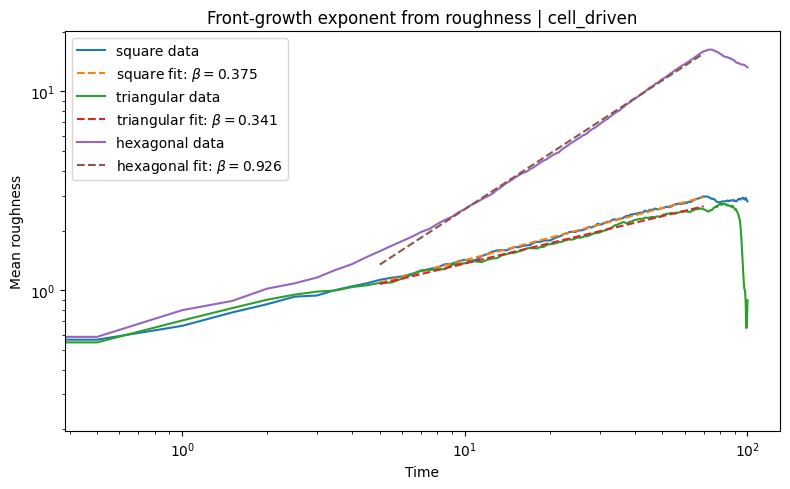

In [17]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]

    t = agg["time"].to_numpy()
    y = agg["mean_roughness"].to_numpy()

    fit = fit_power_law_exponent(
        times=t,
        values=y,
        t_min=t_min_fit,
        t_max=t_max_fit,
    )

    mask = (
        np.isfinite(t)
        & np.isfinite(y)
        & (t > 0.0)
        & (y > 0.0)
        & (t >= t_min_fit)
        & (t <= t_max_fit)
    )

    t_fit = t[mask]
    y_model = fit["C"] * t_fit ** fit["alpha"]

    plt.loglog(t, y, label=f"{lattice_kind} data")
    plt.loglog(
        t_fit,
        y_model,
        "--",
        label=fr"{lattice_kind} fit: $\beta={fit['alpha']:.3f}$",
    )

plt.xlabel("Time")
plt.ylabel("Mean roughness")
plt.title(f"Front-growth exponent from roughness | {update_source}")
plt.legend()
plt.tight_layout()
plt.show()

Uncertainty bands for the mean curves.

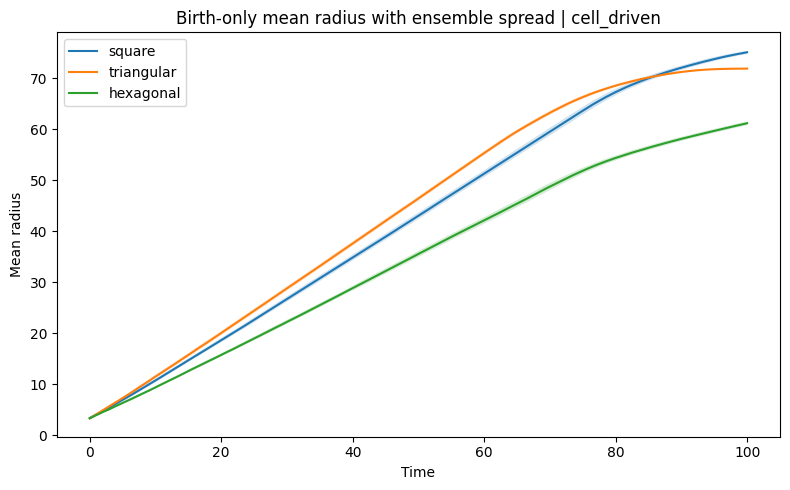

In [18]:
plt.figure(figsize=(8, 5))

for lattice_kind in lattice_kinds:
    agg = ensemble_agg[lattice_kind]

    t = agg["time"].to_numpy()
    y = agg["mean_radius"].to_numpy()
    y_std = agg["std_radius"].to_numpy()

    plt.plot(t, y, label=lattice_kind)
    plt.fill_between(t, y - y_std, y + y_std, alpha=0.2)

plt.xlabel("Time")
plt.ylabel("Mean radius")
plt.title(f"Birth-only mean radius with ensemble spread | {update_source}")
plt.legend()
plt.tight_layout()
plt.show()